# Page Algorithms

## 🟢 Placement vs Replacement
### Placement
When a page or segment is brought into main memory, where should it go?

In paging - **Placement** is usually simple:
- any free page frame can hold any incoming page
- because all frames are the same size

So for paging, placement is not the hard part.
The hard part is usually replacement.

In segmentation or variable partitions

Placement matters more:
- first fit
- best fit
- worst fit

because memory holes have different sizes.

### Replacement
If no free frame is available, which current page should be evicted?

A good replacement policy tries to:
- reduce page faults
- keep useful pages in memory
- exploit locality of reference

#### Importance of Replacement
In paging, placement is mostly easy:
- any free frame works

But once memory is full, replacement policy determines:
- page fault frequency
- disk I/O overhead
- program responsiveness
- whether the system thrashes

So replacement strategy is central to virtual-memory performance.

---

## 🟢 FIFO Replacement
FIFO (First-In, First-Out) replaces the page that has been in memory the longest.

So pages are treated like a queue:
- oldest loaded page leaves first

### Advantage
- very simple to implement
- easy bookkeeping
- low overhead

You just keep track of load order.

### Problem 1: Frequently used pages can still be removed
FIFO does not care whether a page is being used heavily right now.

A page may:
- have been loaded long ago
- still be referenced constantly
- yet FIFO may evict it anyway just because it is old

So FIFO ignores actual usage behavior.

### Problem 2: Belady’s anomaly
Increasing the number of page frames can sometimes produce more page faults

This is surprising because you would expect more memory to always help.

But FIFO can behave badly enough that:
- 3 frames gives fewer faults
- 4 frames gives more faults

#### Example
Reference string: `4, 3, 2, 1, 4, 3, 5, 4, 3, 2, 1, 5`

Results shown:
- 3 frames → fault rate 9/12
- 4 frames → fault rate 10/12

So FIFO is simple, but not always sensible.

---

## 🟢 Optimal Replacement
**OPTIMAL** replaces the page whose next use is farthest in the future, or that will never be used again.

This is the best possible strategy in theory.

### Theory
If you must evict something, the best choice is:
- the page you will not need for the longest time

That minimizes future page faults.

So optimal is a benchmark:
- no practical policy can do better on the same reference string

### Disadvantage

To know which page is needed farthest in the future, the system would need:
- exact knowledge of future memory references

That is usually impossible during actual execution.

Therefore:
- optimal is not implementable exactly
- but it is useful for analysis and comparison

---

## 🟢 LRU Replacement
LRU (Least Recently Used) replaces the page that has not been used for the longest time in the past.

Theory:
- pages used recently are likely to be used again soon
- pages not used for a long time are less likely to be needed soon

This is based on temporal locality.

### Temporal locality
Pages referenced will soon be used again - that is the principle behind LRU.

Programs often reuse recent:
- instructions
- variables
- stack data
- loop bodies

So recent past is a good predictor of near future.

### Why LRU is usually better than FIFO
Unlike FIFO, LRU uses actual access behavior.

So it tends to keep:
- “hot” pages in memory
- rarely used pages as eviction candidates

That usually gives much better performance than FIFO.

### Main problem with exact LRU
It is hard (costly) to implement exactly

To implement true LRU, the system would need to know the exact recency ordering of all pages all the time.

That may require:
- timestamps on every access, or
- moving pages in a stack/list on every access, or
- hardware support

This is expensive, especially because memory references happen constantly.

So exact LRU is conceptually strong but operationally costly.

---

## 🟢 NRU / Pseudo-LRU Approximation
Maintain a recently-used bit for each page/frame.
- set the bit when the page is referenced
- periodically reset all such bits using a timer

Then when replacement is needed:
- prefer a page whose recently-used bit is false / 0

This is sometimes called:
- NRU approximation
- pseudo-LRU in the slides’ wording

### Basic intuition
This gives a rough distinction between:
- pages used recently
- pages not used recently

It does not know the full exact order like true LRU, but it captures enough information to make better choices than FIFO.

### How the slide timeline works
The requests shown are something like:
- `a, b, c, b, [reset], a, d, b, [reset]`

**At first:**
- frames contain a, b, c
- all recently-used bits are T because all were referenced

**After a reset:**
- all bits become F
- the pages are still in memory, but now they are marked “not recently used” until referenced again

**Then:**
- accessing a sets only a’s bit back to T
- b and c stay F

**If a replacement is needed now:**
- b or c is a better victim than a

**Later:**
- access d may replace one of the pages with F
- then d gets marked recently used

**So the timer-based reset creates time windows:**
- referenced in this window → bit = T
- not referenced in this window → bit = F

That is a cheap approximation to “least recently used.”

### Advantage
It is much cheaper than exact LRU because:
- hardware often already has a reference/access bit
- OS only needs periodic resets
- replacement only checks a few bits, not a full usage history

So this gives:
- lower overhead
- acceptable approximation
- common real-system behavior

---

## 🟢 Reduce Footprint: Keep the Active Pages Small
A process may own many virtual pages, but at any instant it usually needs only a small subset of them.

The goal is:
- minimize the number of pages that must be in memory at the same time

Advantage:
- fewer resident pages needed
- fewer page faults
- more room for other processes
- better CPU utilization

This depends on **locality of reference**.

### Locality of reference
A program tends to access:
- the same instructions repeatedly for a while
- nearby data for a while

### Temporal locality
Recently used items are likely to be used again soon.

**Example:**
- loop instructions
- loop-control variables
- top of stack

### Spatial locality
Nearby addresses are likely to be used together.

Example:
- scanning an array sequentially
- adjacent instructions in a basic block

---

## 🟢 Achieve Locality
### A. Structured programming techniques
- small procedures
- avoid arbitrary gotos

#### Advnatage
Smaller, well-structured procedures tend to:
- keep execution in a small code region
- reduce unpredictable jumps
- increase instruction locality

If code jumps randomly across a large program image, many code pages may be touched in a short time. That increases page faults.

So structured code often improves memory behavior as well as readability.

### B. Compiler/layout improvements
Compiler can be clever:
- keep procedures on same page
- put an entire for loop within a single page

#### Advantage
If the hot part of the program fits in one page:
- instruction fetches mostly hit that same page
- loop execution avoids repeated code-page faults

Similarly, if related procedures are placed near each other:
- call sequences touch fewer pages

This is partly a code-generation problem and partly a layout/linking problem.

### C. Sequencing of array references
Even if the algorithm is “the same” mathematically, the order of memory access can change page-fault behavior dramatically. That is because arrays are laid out in memory in a specific order.

---

## 🟢Sequencing of array references

In 2D array with **4-byte integers** and **512-byte pages**:
```
int a[128,128]
for r := 1 to 128
    for c := 1 to 128
        a[r,c] = 0
```
Each page holds:
- 512 / 4 = 128 integers per page

Since the array has 128 × 128 = 16384 integers, total data size is:
- 16384 × 4 = 65536 bytes

and number of pages is:
- 65536 / 512 = 128 pages

That matches the slide:
- 128 ints/page
- 128 data pages

### Why row-major access is good
Most languages like C store 2D arrays in row-major order:
- row 0 contiguous
- then row 1
- then row 2, etc.

Each row here has 128 integers, which is exactly:
- 128 × 4 bytes = 512 bytes = one page

So one row fits in one page.

If you access:
```
for r
    for c
        a[r,c]
```
then for a fixed row r, you sweep across columns c = 1..128, touching contiguous memory within that one row/page. Therefore:
- row 1 → one page fault
- row 2 → one page fault
- ...
- row 128 → one page fault

Total:
- 128 page faults

---

## 🟢 Working Set - OS Frame Allocation Policy
A process does not need all of its allocated frames all the time.

If some resident frames contain pages that are not being used:
- those frames are effectively wasted

So the OS should dynamically adjust the number of frames given to each process.

### Definition
the set of pages a process has referenced during the last window of execution
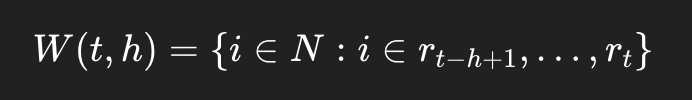

Meaning:
- at time t
- look back over the most recent h references
- collect all distinct pages referenced in that window

That set is the working set.

### Interpretation
If those pages are in memory, the process is likely to run with relatively few faults, because they represent the pages it is actively using now.

So the working set approximates:
- the process’s current locality
- the number of frames it really needs right now

### Advantage
If a process has fewer frames than its working set:
- it faults frequently
- spends more time waiting for I/O
- gets little useful CPU time

If it has many more frames than its working set:
- some frames are wasted
- other processes could use them better

So the working-set idea helps the OS balance memory among processes.

### Working Set Example
| t | reference | last 3 refs | working set |
| - | --------- | ----------- | ----------- |
| 1 | 1         | 1           | {1}         |
| 2 | 2         | 1,2         | {1,2}       |
| 3 | 1         | 1,2,1       | {1,2}       |
| 4 | 3         | 2,1,3       | {1,2,3}     |
| 5 | 2         | 1,3,2       | {1,2,3}     |
